
# NEM SA1 — Random Forest Classifier for Negative Price Prediction (v2)

**Input:** `sa1_merged_eda.csv` — the cleaned, merged dataset produced by the EDA notebook containing 2 years of AEMO dispatch data (2023–2024) at 30-minute resolution.

**Pipeline overview:**
1. Load data & create binary target
2. Drop redundant features (identified by EDA multicollinearity analysis)
3. Engineer lag features at spaced intervals (informed by ACF/PACF analysis)
4. Chronological train/test split
5. Train Random Forest with class balancing
6. Evaluate: confusion matrix, precision, recall, F1, ROC-AUC
7. Feature importance analysis



## 1. Setup & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Suppress sklearn convergence warnings — keeps output clean
warnings.filterwarnings('ignore')

# Plot settings — higher DPI for sharper inline plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)

print('All imports loaded successfully.')

All imports loaded successfully.



## 2. Load the Merged EDA Dataset

This CSV was saved at the end of the EDA notebook (`NEM_EDA_Correlation.ipynb`). It contains the merged data from three AEMO tables:
- **DISPATCHPRICE** — the spot price (RRP) and FCAS prices
- **DISPATCHREGIONSUM** — demand, supply, renewable generation, curtailment
- **DISPATCHINTERCONNECTORRES** — Heywood interconnector flow (SA ↔ VIC)

All tables were filtered to `INTERVENTION=0` (real market outcomes only) and resampled to 30-minute intervals during the EDA phase.

In [2]:
DATA_DIR = '../../data'
df = pd.read_csv(os.path.join(DATA_DIR, 'sa1_merged_eda.csv'), parse_dates=['SETTLEMENTDATE'])

# Make sure the data loaded correctly
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range:    {df.SETTLEMENTDATE.min()} to {df.SETTLEMENTDATE.max()}')
print(f'\nColumn list:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2d}. {col}')

Dataset shape: 35,041 rows x 27 columns
Date range:    2023-01-01 00:00:00 to 2024-12-31 00:00:00

Column list:
   1. SETTLEMENTDATE
   2. RRP
   3. RAISE6SECRRP
   4. RAISE60SECRRP
   5. RAISE5MINRRP
   6. RAISEREGRRP
   7. LOWER6SECRRP
   8. LOWER60SECRRP
   9. LOWER5MINRRP
  10. LOWERREGRRP
  11. TOTALDEMAND
  12. AVAILABLEGENERATION
  13. AVAILABLELOAD
  14. DEMANDFORECAST
  15. DISPATCHABLEGENERATION
  16. DISPATCHABLELOAD
  17. NETINTERCHANGE
  18. EXCESSGENERATION
  19. INITIALSUPPLY
  20. CLEAREDSUPPLY
  21. TOTALINTERMITTENTGENERATION
  22. UIGF
  23. SEMISCHEDULE_CLEAREDMW
  24. SEMISCHEDULE_COMPLIANCEMW
  25. MWFLOW_V-SA
  26. MWLOSSES_V-SA
  27. CURTAILMENT_MW


## 3. Create the Binary Target Variable

This is the column the model will predict. For each 30-minute interval:
- **1** = the price was negative (RRP < $0/MWh)
- **0** = the price was zero or positive

This makes the task a **binary classification** problem — the model outputs a yes/no prediction, not a dollar amount.

In [3]:
# Create the target: 1 if price is negative, 0 otherwise
df['NEG_PRICE'] = (df['RRP'] < 0).astype(int)

# Check the class balance — how common are negative price events?
neg_count = df['NEG_PRICE'].sum()
total = len(df)
neg_pct = df['NEG_PRICE'].mean() * 100

print(f'Total intervals:    {total:,}')
print(f'Negative intervals: {neg_count:,} ({neg_pct:.1f}%)')
print(f'Normal intervals:   {total - neg_count:,} ({100 - neg_pct:.1f}%)')
print(f'\nClass ratio: ~1 negative for every {int((total - neg_count) / neg_count)} normal intervals')

Total intervals:    35,041
Negative intervals: 9,125 (26.0%)
Normal intervals:   25,916 (74.0%)

Class ratio: ~1 negative for every 2 normal intervals


## 4. Drop Redundant Features

The EDA correlation heatmap identified several feature pairs that are near-duplicates:

| Pair | Spearman correlation | Action |
|------|---------------------|--------|
| CLEAREDSUPPLY ↔ INITIALSUPPLY | 1.00 | Drop INITIALSUPPLY — identical information |
| EXCESSGENERATION | NaN correlations | Drop — column is mostly zeros/empty |
| TOTALINTERMITTENTGENERATION | NaN correlations | Drop — likely redundant with UIGF |

Keeping redundant features wastes model capacity and can make feature importance harder to interpret. The EDA showed these contribute no additional signal.

In [4]:
# Features to drop based on EDA multicollinearity analysis
drop_cols = [
    'INITIALSUPPLY',              # Perfect correlation (1.00) with CLEAREDSUPPLY
    'EXCESSGENERATION',           # NaN correlations in EDA — mostly zeros
    'TOTALINTERMITTENTGENERATION', # NaN correlations in EDA — redundant with UIGF
]

# Only drop columns that actually exist in the dataframe
drop_existing = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_existing)

print(f'Dropped {len(drop_existing)} redundant features: {drop_existing}')
print(f'Remaining columns: {df.shape[1]}')

Dropped 3 redundant features: ['INITIALSUPPLY', 'EXCESSGENERATION', 'TOTALINTERMITTENTGENERATION']
Remaining columns: 25


## 5. Engineer Lag Features

Lag features capture **temporal memory** — what happened in previous intervals that might predict the current price.

### Why spaced lags instead of consecutive?

The EDA's PACF analysis showed that after lag 1, consecutive lags add almost no new information — they're highly correlated with each other (multicollinearity). Using spaced lags captures different time horizons without redundancy:

| Lag | Time lookback | What it captures |
|-----|--------------|-----------------|
| lag_1 | 30 minutes | Most recent market state (strongest signal) |
| lag_6 | 3 hours | Short-term trend direction |
| lag_12 | 6 hours | Medium-term context (half a trading day) |
| lag_48 | 24 hours | Same time yesterday (diurnal cycle) |

The EDA lag correlation plot confirmed that RRP's autocorrelation drops sharply by lag 6, flattens, then bumps back up at lag 48 — matching the 24-hour demand/solar cycle.

In [5]:
# Define which features get lag columns and at which intervals
# These choices are informed by the EDA correlation rankings:
#   - RRP: price memory (ACF showed strong lag-1, diurnal bump at lag-48)
#   - TOTALDEMAND: demand trends (decays by lag 12, recovers at lag 48)
#   - CURTAILMENT_MW: oversupply signal (top-ranked feature by Spearman)
#   - NETINTERCHANGE: export flow trends (how much SA is sending to VIC)

lag_config = {
    'RRP':             [1, 6, 12, 48],  # Price history at multiple horizons
    'TOTALDEMAND':     [1, 6, 12],      # Demand trends (no lag_48 — recovers anyway)
    'CURTAILMENT_MW':  [1, 6],          # Recent curtailment pressure
    'NETINTERCHANGE':  [1, 6],          # Recent interconnector flow direction
}

# Create each lag column by shifting the original column backward in time
# shift(1) means "the value from 1 interval ago"
for col, lags in lag_config.items():
    for lag in lags:
        new_col = f'{col}_lag{lag}'
        df[new_col] = df[col].shift(lag)
        print(f'  Created: {new_col:<30} ({lag * 30} min lookback)')

# The first 48 rows will have NaN values because there's no data before the start
# We have to drop these — the model can't train on missing values
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'\nDropped {rows_before - len(df)} rows with NaN from lag creation')
print(f'Remaining: {len(df):,} rows (lost ~1 day of data — negligible)')

  Created: RRP_lag1                       (30 min lookback)
  Created: RRP_lag6                       (180 min lookback)
  Created: RRP_lag12                      (360 min lookback)
  Created: RRP_lag48                      (1440 min lookback)
  Created: TOTALDEMAND_lag1               (30 min lookback)
  Created: TOTALDEMAND_lag6               (180 min lookback)
  Created: TOTALDEMAND_lag12              (360 min lookback)
  Created: CURTAILMENT_MW_lag1            (30 min lookback)
  Created: CURTAILMENT_MW_lag6            (180 min lookback)
  Created: NETINTERCHANGE_lag1            (30 min lookback)
  Created: NETINTERCHANGE_lag6            (180 min lookback)

Dropped 48 rows with NaN from lag creation
Remaining: 34,993 rows (lost ~1 day of data — negligible)


## 6. Define the Feature Set

These are the columns the Random Forest will use as inputs. They fall into four categories, all informed by the EDA Spearman correlation rankings:

1. **Demand signals** — TOTALDEMAND, CLEAREDSUPPLY, DEMANDFORECAST, etc.
2. **Renewable/curtailment signals** — CURTAILMENT_MW, UIGF, SEMISCHEDULE_CLEAREDMW, etc.
3. **Interconnector signals** — NETINTERCHANGE, MWFLOW_V-SA
4. **FCAS stress signals** — RAISE and LOWER frequency control prices
5. **Lag features** — Time-shifted versions of key features (created above)

We exclude `SETTLEMENTDATE` (not a numeric feature), `RRP` (that's the price itself — including it would be cheating), and `NEG_PRICE` (that's the target we're predicting).

In [6]:
# Everything except the timestamp, the raw price, and the target label
exclude = ['SETTLEMENTDATE', 'RRP', 'NEG_PRICE']
feature_cols = [c for c in df.columns if c not in exclude]

print(f'Total features: {len(feature_cols)}')
print(f'\nFeature list:')
for i, col in enumerate(feature_cols):
    print(f'  {i+1:2d}. {col}')

Total features: 33

Feature list:
   1. RAISE6SECRRP
   2. RAISE60SECRRP
   3. RAISE5MINRRP
   4. RAISEREGRRP
   5. LOWER6SECRRP
   6. LOWER60SECRRP
   7. LOWER5MINRRP
   8. LOWERREGRRP
   9. TOTALDEMAND
  10. AVAILABLEGENERATION
  11. AVAILABLELOAD
  12. DEMANDFORECAST
  13. DISPATCHABLEGENERATION
  14. DISPATCHABLELOAD
  15. NETINTERCHANGE
  16. CLEAREDSUPPLY
  17. UIGF
  18. SEMISCHEDULE_CLEAREDMW
  19. SEMISCHEDULE_COMPLIANCEMW
  20. MWFLOW_V-SA
  21. MWLOSSES_V-SA
  22. CURTAILMENT_MW
  23. RRP_lag1
  24. RRP_lag6
  25. RRP_lag12
  26. RRP_lag48
  27. TOTALDEMAND_lag1
  28. TOTALDEMAND_lag6
  29. TOTALDEMAND_lag12
  30. CURTAILMENT_MW_lag1
  31. CURTAILMENT_MW_lag6
  32. NETINTERCHANGE_lag1
  33. NETINTERCHANGE_lag6


## 7. Chronological Train/Test Split

**This is time series data — we cannot use a random split.**

A random split would let the model see future intervals during training, which leaks information and inflates performance. Instead, we split by date:

- **Training set:** Everything before 1 July 2024 (~18 months)
- **Test set:** Everything from 1 July 2024 onward (~6 months)

This simulates a real deployment: "learn from the past, predict the future." The model has never seen any test data during training.

In [ ]:
# Split point: 1 July 2024
# Training gets ~75% of data, test gets ~25%
split_date = pd.Timestamp('2024-01-01')

train = df[df['SETTLEMENTDATE'] < split_date].copy()
test  = df[df['SETTLEMENTDATE'] >= split_date].copy()

# Separate features (X) from target (y)
X_train = train[feature_cols]
X_test  = test[feature_cols]
y_train = train['NEG_PRICE']
y_test  = test['NEG_PRICE']

print(f'Training set: {len(train):,} rows')
print(f'  Date range: {train.SETTLEMENTDATE.min().date()} to {train.SETTLEMENTDATE.max().date()}')
print(f'  Negative rate: {y_train.mean():.1%}')
print(f'\nTest set: {len(test):,} rows')
print(f'  Date range: {test.SETTLEMENTDATE.min().date()} to {test.SETTLEMENTDATE.max().date()}')
print(f'  Negative rate: {y_test.mean():.1%}')

Training set: 26,208 rows
  Date range: 2023-01-02 to 2024-06-30
  Negative rate: 23.5%

Test set: 8,785 rows
  Date range: 2024-07-01 to 2024-12-31
  Negative rate: 33.5%


## 8. Train the Random Forest

### Key hyperparameters explained:

- **`n_estimators=200`** — Build 200 decision trees and average their votes. More trees = more stable predictions, at the cost of slightly longer training time.
- **`max_depth=15`** — Each tree can ask at most 15 levels of yes/no questions. This prevents overfitting — without a limit, trees would memorise the training data perfectly but fail on new data.
- **`min_samples_leaf=20`** — Every final prediction group (leaf) must contain at least 20 training examples. This smooths out noisy predictions from tiny groups.
- **`class_weight='balanced'`** — Automatically upweights the minority class (negative prices). Without this, the model would learn that predicting "normal" every time gives decent accuracy, but it would never detect negative events.
- **`random_state=42`** — Fixes the random seed so results are reproducible. Anyone running this notebook gets the same numbers.
- **`n_jobs=-1`** — Use all available CPU cores to train in parallel (faster).

In [8]:
# Random Forest does NOT need feature scaling (unlike Logistic Regression).
# Tree-based models split on thresholds, so the absolute scale of features
# doesn't matter — a split at 1000 MW works the same as a split at 0.5.

rf = RandomForestClassifier(
    n_estimators=200,       # Number of trees in the forest
    max_depth=15,           # Maximum depth of each tree
    min_samples_leaf=20,    # Minimum samples required in each leaf node
    class_weight='balanced', # Handle class imbalance (negative prices are ~26%)
    random_state=42,        # Reproducibility
    n_jobs=-1               # Use all CPU cores
)

# Fit the model — this is where the learning happens
# The model looks at all training intervals and learns which combinations
# of feature values tend to precede negative vs normal prices
rf.fit(X_train, y_train)

print(f'Random Forest trained successfully.')
print(f'  Trees: {rf.n_estimators}')
print(f'  Features used: {rf.n_features_in_}')
print(f'  Training samples: {len(X_train):,}')

Random Forest trained successfully.
  Trees: 200
  Features used: 33
  Training samples: 26,208


## 9. Generate Predictions on the Test Set

The model now makes two types of predictions for each test interval:
- **Class prediction** — binary 0 or 1 (will it be negative or not?)
- **Probability prediction** — a number between 0.0 and 1.0 (how confident is the model?)

The probability is useful for ROC-AUC and for real-world use — a battery operator might only act when the model says >80% chance of negative price.

In [9]:
# Class predictions: 0 or 1
y_pred = rf.predict(X_test)

# Probability predictions: probability of class 1 (negative price)
# predict_proba returns probabilities for both classes — we take column 1
y_prob = rf.predict_proba(X_test)[:, 1]

print(f'Predictions generated for {len(X_test):,} test intervals')
print(f'\nPredicted distribution:')
print(f'  Predicted negative: {(y_pred == 1).sum():,}')
print(f'  Predicted normal:   {(y_pred == 0).sum():,}')
print(f'\nActual distribution:')
print(f'  Actually negative:  {(y_test == 1).sum():,}')
print(f'  Actually normal:    {(y_test == 0).sum():,}')

Predictions generated for 8,785 test intervals

Predicted distribution:
  Predicted negative: 3,152
  Predicted normal:   5,633

Actual distribution:
  Actually negative:  2,947
  Actually normal:    5,838


## 10. Evaluation Metrics

### Why not just use accuracy?

Because negative prices are the minority class (~26%). A model that **always predicts "normal"** would get ~74% accuracy while finding **zero** negative events. Accuracy is misleading for imbalanced classification.

### Metrics we use instead:

| Metric | What it measures | In plain English |
|--------|-----------------|-----------------|
| **Precision** | Of all intervals the model flagged as negative, how many actually were? | "When it says negative, can I trust it?" |
| **Recall** | Of all intervals that were actually negative, how many did the model catch? | "Does it miss many real negative events?" |
| **F1 Score** | Harmonic mean of precision and recall | Balances both — the single number to compare models |
| **ROC-AUC** | Area under the ROC curve | How well the model separates the two classes overall |

In [10]:
# Calculate all evaluation metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

# Print a clean summary
print('=' * 50)
print('RANDOM FOREST — EVALUATION RESULTS')
print('=' * 50)
print(f'Accuracy:   {acc:.4f}  ({acc:.1%})')
print(f'Precision:  {prec:.4f}  ({prec:.1%})')
print(f'Recall:     {rec:.4f}  ({rec:.1%})')
print(f'F1 Score:   {f1:.4f}  ({f1:.1%})')
print(f'ROC-AUC:    {auc:.4f}  ({auc:.1%})')
print('=' * 50)

# Full classification report — includes per-class breakdown
print('\nDetailed Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Normal (0)', 'Negative (1)']
))

RANDOM FOREST — EVALUATION RESULTS
Accuracy:   0.9489  (94.9%)
Precision:  0.8963  (89.6%)
Recall:     0.9586  (95.9%)
F1 Score:   0.9264  (92.6%)
ROC-AUC:    0.9912  (99.1%)

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.94      0.96      5838
Negative (1)       0.90      0.96      0.93      2947

    accuracy                           0.95      8785
   macro avg       0.94      0.95      0.94      8785
weighted avg       0.95      0.95      0.95      8785



## 11. Confusion Matrix

The confusion matrix shows exactly where the model gets it right and wrong:

|  | Predicted Normal | Predicted Negative |
|--|-----------------|-------------------|
| **Actually Normal** | True Negative (correct) | False Positive (false alarm) |
| **Actually Negative** | False Negative (missed it) | True Positive (correctly caught) |

The bottom-left cell (False Negatives) is the most important for our use case — these are negative price events the model failed to predict. A battery operator relying on this model would miss those opportunities.

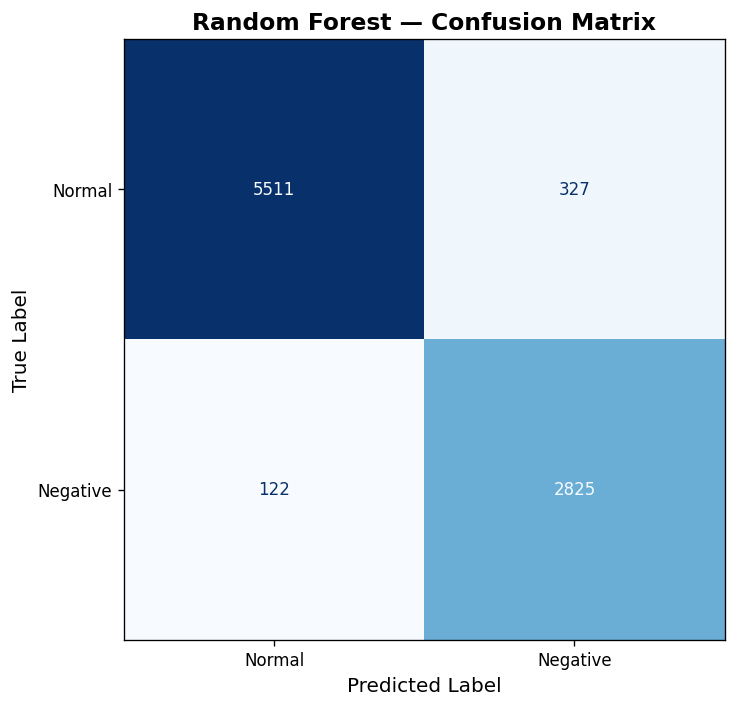

In [11]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Normal', 'Negative'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## 12. ROC Curve

The ROC (Receiver Operating Characteristic) curve shows the trade-off between:
- **True Positive Rate** (recall) — catching real negative events
- **False Positive Rate** — triggering false alarms

A perfect model hugs the top-left corner (AUC = 1.0). A random coin flip follows the diagonal (AUC = 0.5). The further the curve is from the diagonal, the better the model is at separating negative from normal intervals.

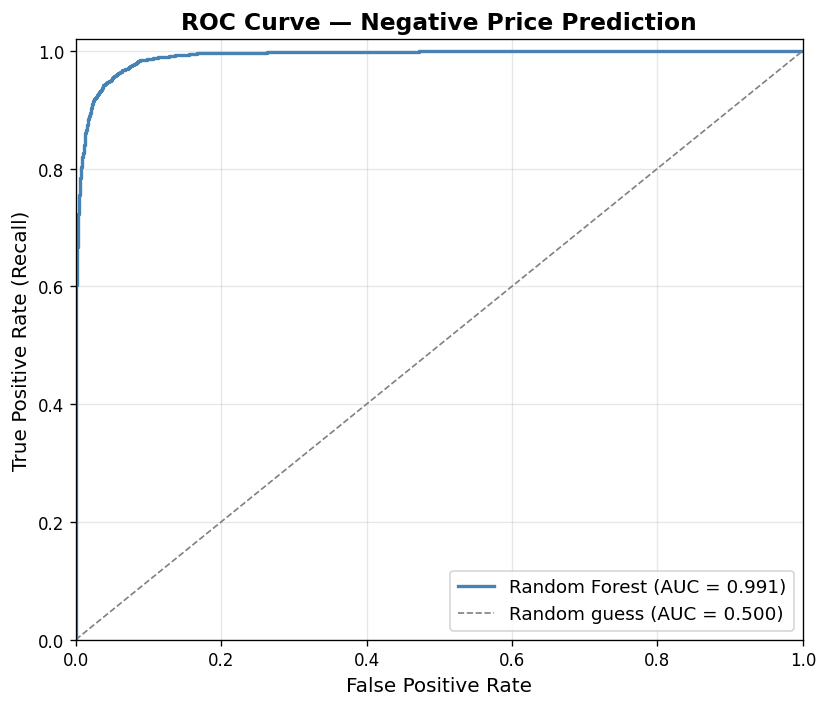

In [12]:
# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Negative Price Prediction', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Feature Importance

Random Forest calculates how much each feature contributes to the model's predictions using **Gini importance** — features that create cleaner splits between negative and normal intervals score higher.

### What to look for:
- If **RRP_lag1** dominates, the model is mostly "peeking" at the most recent price. This is technically valid but means the model's value comes from short-term persistence, not from understanding market fundamentals.
- If **CURTAILMENT_MW** and **UIGF** rank high, the model is learning the physical oversupply mechanism — which is more interpretable and useful.
- Features near zero importance can be removed without affecting performance.

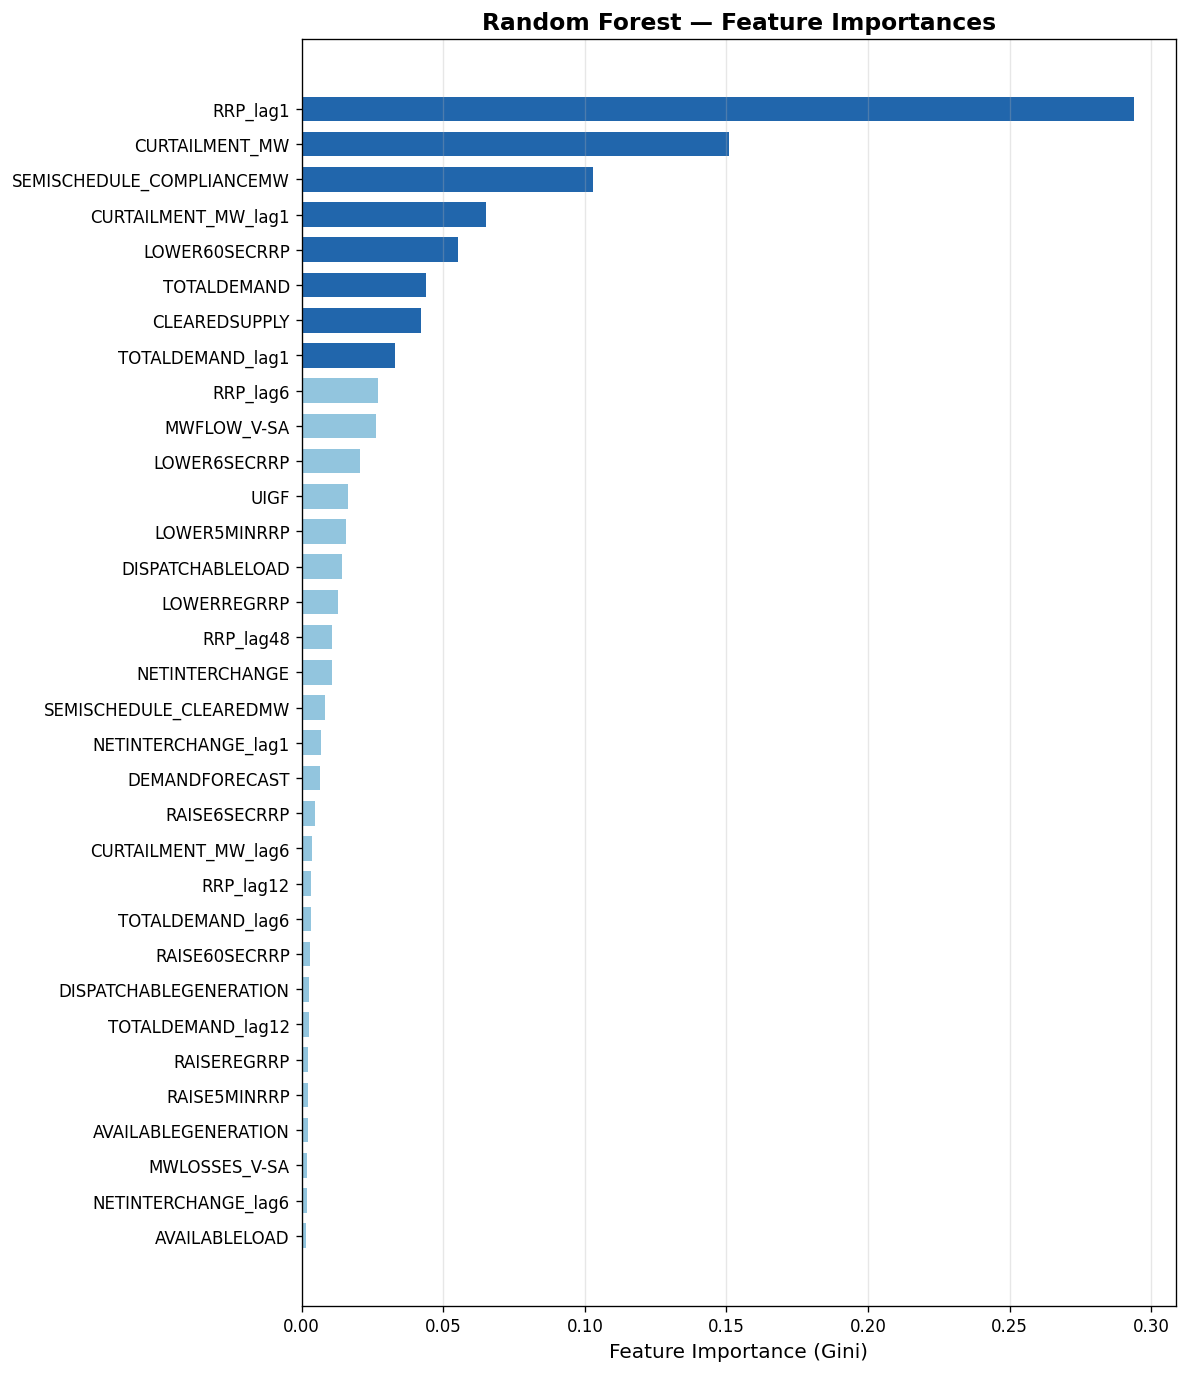


Top 10 Most Important Features:
---------------------------------------------
  RRP_lag1                       0.2940  ██████████████████████████████████████████████████████████
  CURTAILMENT_MW                 0.1510  ██████████████████████████████
  SEMISCHEDULE_COMPLIANCEMW      0.1028  ████████████████████
  CURTAILMENT_MW_lag1            0.0652  █████████████
  LOWER60SECRRP                  0.0552  ███████████
  TOTALDEMAND                    0.0441  ████████
  CLEAREDSUPPLY                  0.0422  ████████
  TOTALDEMAND_lag1               0.0331  ██████
  RRP_lag6                       0.0269  █████
  MWFLOW_V-SA                    0.0262  █████


In [13]:
# Extract feature importances and sort them
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)  # ascending for horizontal bar chart

# Plot — horizontal bar chart with all features ranked
fig, ax = plt.subplots(figsize=(10, max(6, len(importances) * 0.35)))
colors = ['#2166ac' if v > importances.quantile(0.75) else '#92c5de' 
          for v in importances.values]
ax.barh(importances.index, importances.values, color=colors, edgecolor='none', height=0.7)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print top 10 as a clean table
print('\nTop 10 Most Important Features:')
print('-' * 45)
for feat, imp in importances.sort_values(ascending=False).head(10).items():
    bar = '█' * int(imp * 200)  # visual bar
    print(f'  {feat:<30} {imp:.4f}  {bar}')

## 14. Prediction Timeline — Visual Check

Plot the model's predicted probabilities over time against actual negative price events. This shows whether the model's confidence aligns with real negative price episodes or whether it raises false alarms during normal periods.

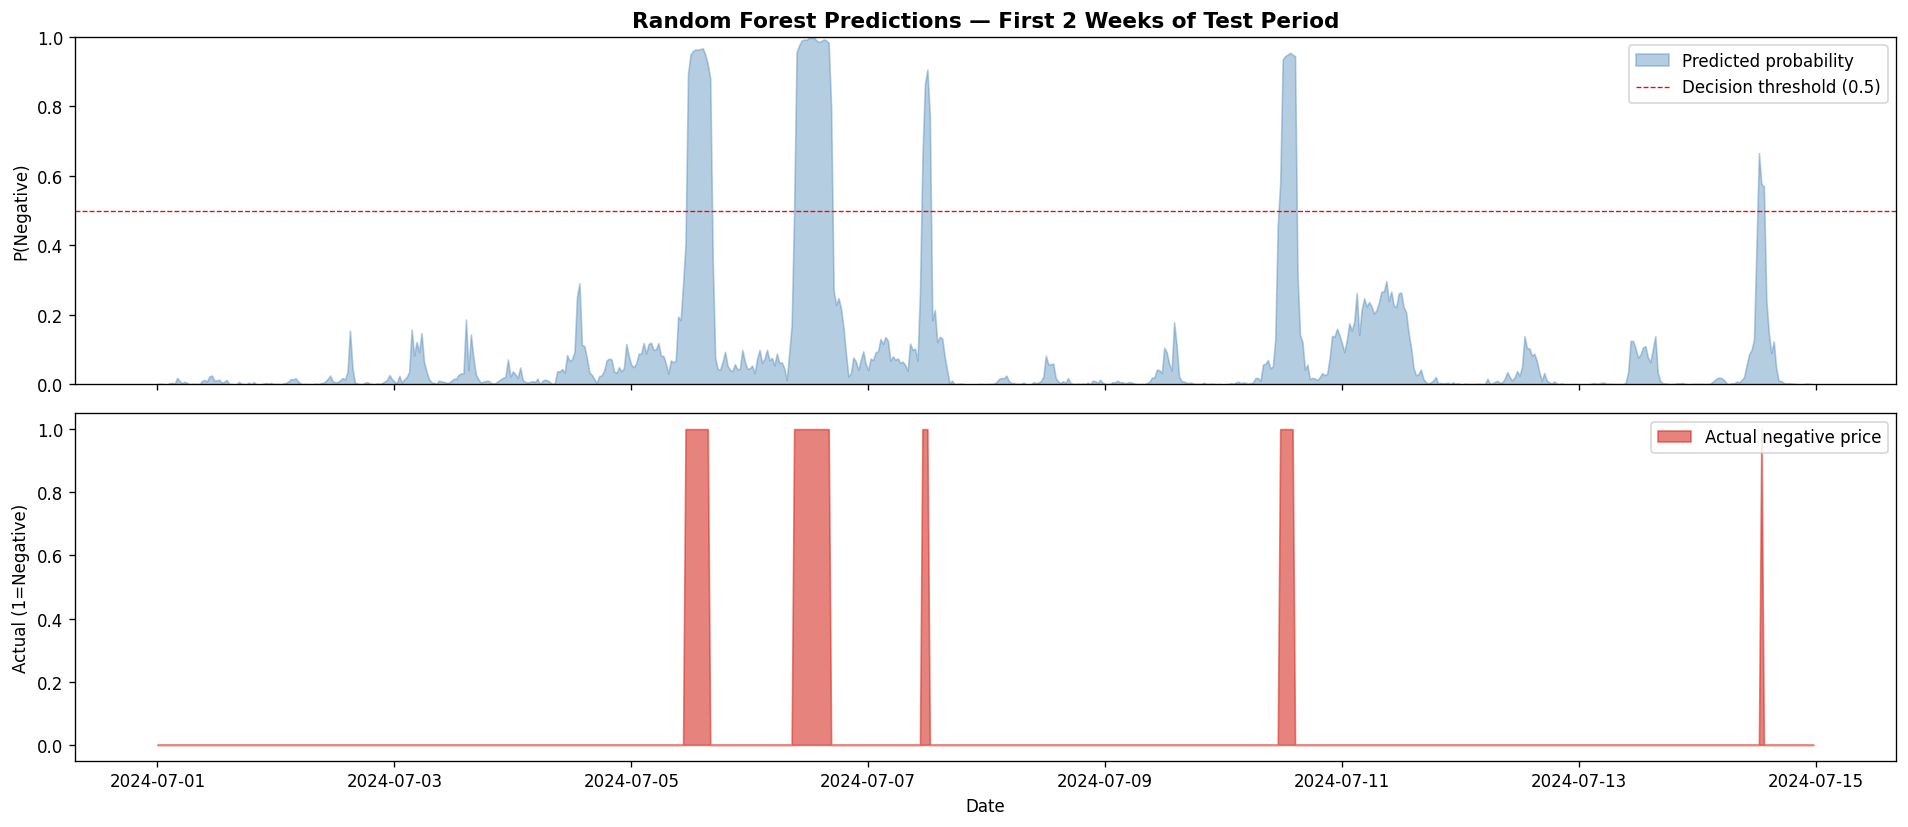

In [14]:
# Create a timeline of predictions vs actuals for the test period
timeline = test[['SETTLEMENTDATE', 'NEG_PRICE']].copy()
timeline['predicted_prob'] = y_prob
timeline['predicted_class'] = y_pred

# Plot 2 weeks of test data for a readable view
sample_start = test['SETTLEMENTDATE'].min()
sample_end = sample_start + pd.Timedelta(days=14)
sample = timeline[(timeline.SETTLEMENTDATE >= sample_start) & 
                   (timeline.SETTLEMENTDATE < sample_end)]

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Top panel: predicted probability
axes[0].fill_between(sample.SETTLEMENTDATE, sample.predicted_prob, 
                      alpha=0.4, color='steelblue', label='Predicted probability')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Decision threshold (0.5)')
axes[0].set_ylabel('P(Negative)')
axes[0].set_title('Random Forest Predictions — First 2 Weeks of Test Period', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].set_ylim([0, 1])

# Bottom panel: actual negative events
axes[1].fill_between(sample.SETTLEMENTDATE, sample.NEG_PRICE, 
                      alpha=0.6, color='#d73027', label='Actual negative price')
axes[1].set_ylabel('Actual (1=Negative)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper right')
axes[1].set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()